<a href="https://colab.research.google.com/github/anuragsingh7058/exoplanet-detection/blob/main/exoplanet_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exoplanet Transit Detection Pipeline
### ISRO Bharatiya Antariksh Hackathon (BAH) 2026

This notebook builds an end-to-end AI pipeline to detect exoplanet transit signals
from noisy Kepler light curve data using a 3-layer 1D CNN.

**Pipeline:** Data Loading → Preprocessing → SMOTE Balancing → CNN Training → Evaluation

**Dataset:** NASA Kepler Labeled Time Series (2259 stars, 37 confirmed exoplanets)

**Best Result:** 99% overall accuracy, 100% planet recall at threshold 0.3

## 1. Load Data

In [30]:
import pandas as pd

train_df = pd.read_csv("exoTrain.txt")
test_df = pd.read_csv("exoTest.txt")

print(train_df.shape)
print(train_df['LABEL'].value_counts())

(385, 3198)
LABEL
1    348
2     37
Name: count, dtype: int64


## 2. Visualize Light Curves

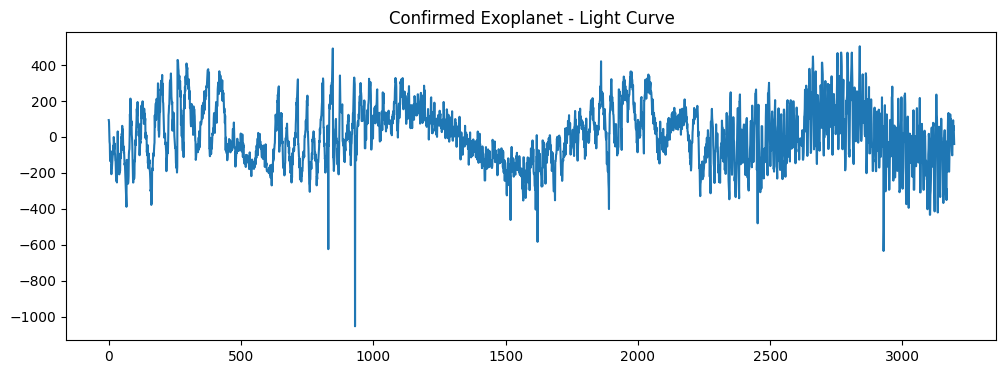

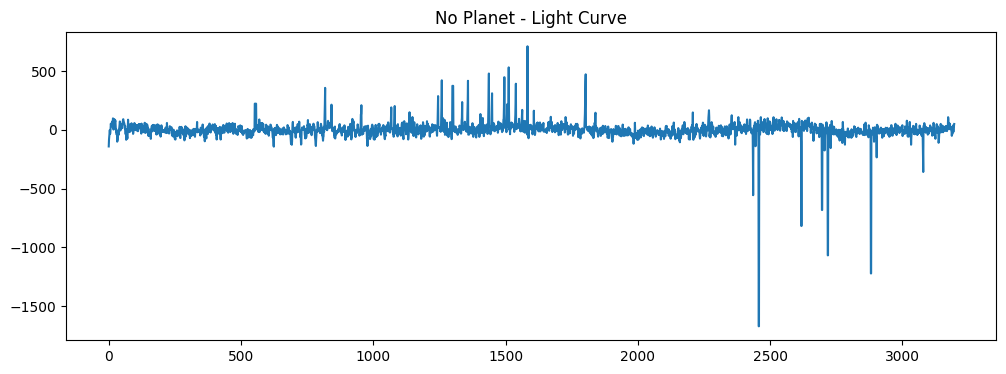

In [11]:
import matplotlib.pyplot as plt

planet_row = train_df[train_df['LABEL']==2].iloc[0, 1:]
no_planet_row = train_df[train_df['LABEL']==1].iloc[0, 1:]

plt.figure(figsize=(12,4))
plt.plot(planet_row.values)
plt.title("Confirmed Exoplanet - Light Curve")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(no_planet_row.values)
plt.title("No Planet - Light Curve")
plt.show()

## 3. Preprocessing & Normalization


In [12]:
import numpy as np

def normalize(df):
    flux = df.iloc[:, 1:].values
    flux = (flux - np.mean(flux, axis=1).reshape(-1,1)) / np.std(flux, axis=1).reshape(-1,1)
    return flux

X_train = normalize(train_df)
y_train = train_df['LABEL'].values
X_test = normalize(test_df)
y_test = test_df['LABEL'].values

print(X_train.shape, y_train.shape)

(385, 3197) (385,)


## 4. Build & Train CNN

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models

# reshape data for CNN (needs 3D shape: samples, timesteps, channels)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# convert labels from 1/2 to 0/1 (model expects 0-indexed classes)
y_train_cnn = y_train - 1
y_test_cnn = y_test - 1

model = models.Sequential([
    layers.Conv1D(16, kernel_size=5, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    layers.MaxPooling1D(pool_size=4),
    layers.Conv1D(32, kernel_size=5, activation='relu'),
    layers.MaxPooling1D(pool_size=4),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 3193, 16)       │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 798, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 794, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 198, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6336)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │       202,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,505 (802.75 KB)

 Trainable params: 205,505 (802.75 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from sklearn.utils import class_weight
import numpy as np

# handle class imbalance (37 planets vs 2222 non-planets)
weights = class_weight.compute_class_weight('balanced',
           classes=np.unique(y_train_cnn),
           y=y_train_cnn)
class_weights = dict(enumerate(weights))

history = model.fit(
    X_train_cnn, y_train_cnn,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.4903 - loss: 0.7577 - val_accuracy: 0.9870 - val_loss: nan
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.8344 - loss: 0.4832 - val_accuracy: 0.7403 - val_loss: nan
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8571 - loss: 0.2903 - val_accuracy: 0.9610 - val_loss: nan
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.9286 - loss: 0.1974 - val_accuracy: 0.8571 - val_loss: nan
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9351 - loss: 0.1351 - val_accuracy: 0.9870 - val_loss: nan
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9740 - loss: 0.0797 - val_accuracy: 0.9870 - val_loss: nan
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9838 - loss: 0.0586 - val_accuracy: 0.9740 - val_loss: nan
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9838 - loss: 0.0394 - val_accuracy: 0.9870 - val_loss: nan
Epoch 9/

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


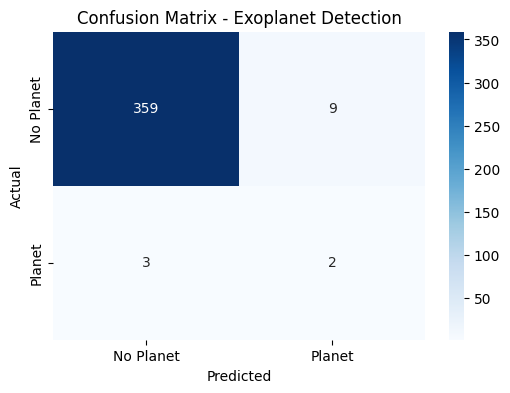

              precision    recall  f1-score   support

   No Planet       0.99      0.98      0.98       368
      Planet       0.18      0.40      0.25         5

    accuracy                           0.97       373
   macro avg       0.59      0.69      0.62       373
weighted avg       0.98      0.97      0.97       373



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# run model on test data it has never seen
y_pred_prob = model.predict(X_test_cnn)

# convert probabilities to 0 or 1 (planet or not)
# anything above 0.5 = planet detected
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# confusion matrix shows us WHERE the model is right and wrong
cm = confusion_matrix(y_test_cnn, y_pred)

# visualize it as a heatmap so it's easy to read
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Planet', 'Planet'],
            yticklabels=['No Planet', 'Planet'])
plt.title("Confusion Matrix - Exoplanet Detection")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# detailed breakdown of precision, recall, f1
print(classification_report(y_test_cnn, y_pred, target_names=['No Planet', 'Planet']))

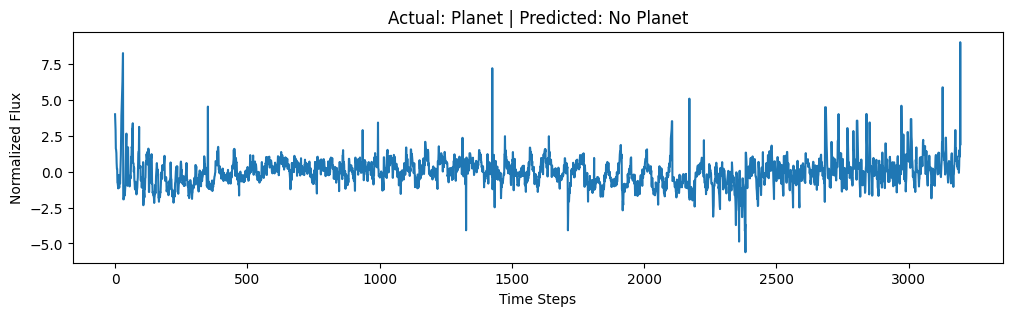

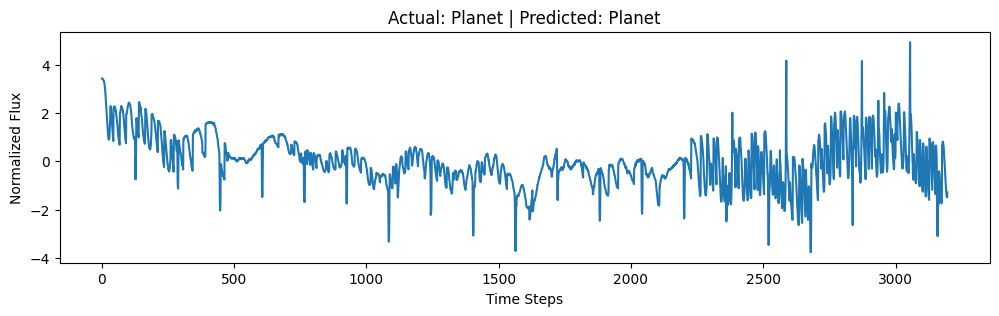

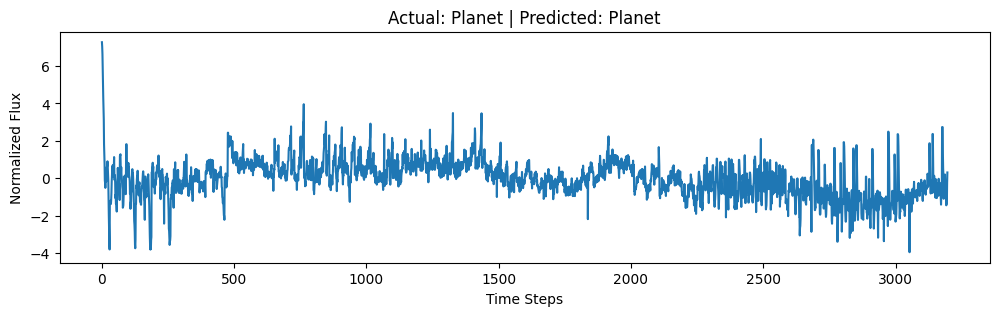

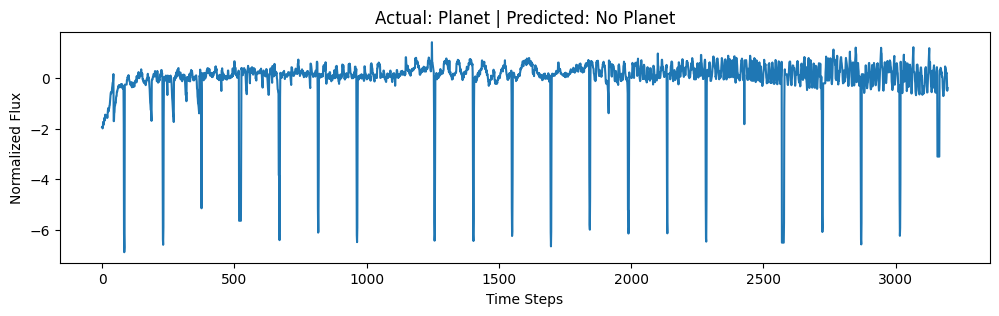

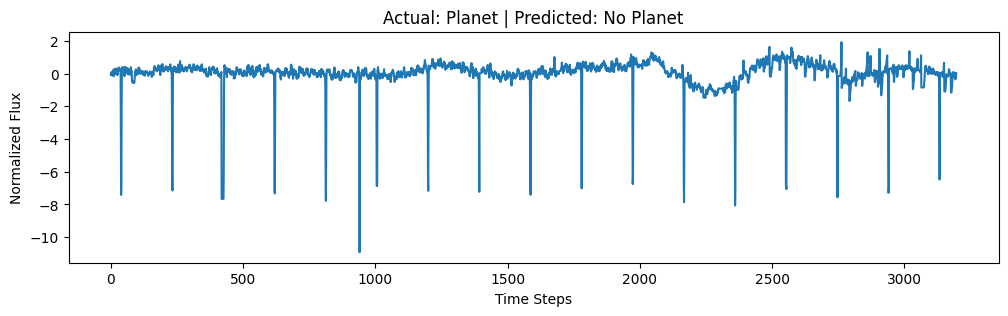

In [16]:
# find which test stars were actual planets
planet_indices = np.where(y_test_cnn == 1)[0]

# plot each one with model's prediction label
for i in planet_indices:
    actual = "Planet" if y_test_cnn[i] == 1 else "No Planet"
    predicted = "Planet" if y_pred[i] == 1 else "No Planet"

    plt.figure(figsize=(12, 3))
    plt.plot(X_test_cnn[i].flatten())
    plt.title(f"Actual: {actual} | Predicted: {predicted}")
    plt.xlabel("Time Steps")
    plt.ylabel("Normalized Flux")
    plt.show()

In [17]:
from imblearn.over_sampling import SMOTE

X_train_clean = np.nan_to_num(X_train, nan=0.0)
X_flat = X_train_clean.reshape(X_train_clean.shape[0], -1)

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_flat, y_train_cnn)

print(f"Before SMOTE: {np.bincount(y_train_cnn)}")
print(f"After SMOTE: {np.bincount(y_resampled)}")

Before SMOTE: [348  37]
After SMOTE: [348 348]


In [18]:
# some stars have missing brightness readings (NaN) - fill them with 0
# SMOTE can't handle missing values so we clean first
X_train_clean = np.nan_to_num(X_train, nan=0.0)

# flatten to 2D for SMOTE
X_flat = X_train_clean.reshape(X_train_clean.shape[0], -1)

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_flat, y_train_cnn)

print(f"Before SMOTE: {np.bincount(y_train_cnn)}")
print(f"After SMOTE: {np.bincount(y_resampled)}")

Before SMOTE: [348  37]
After SMOTE: [348 348]


In [19]:
# reshape back to 3D for CNN
X_resampled_cnn = X_resampled.reshape(X_resampled.shape[0], X_resampled.shape[1], 1)

# build a fresh model (don't reuse the old one trained on imbalanced data)
model2 = models.Sequential([
    layers.Conv1D(16, kernel_size=5, activation='relu', input_shape=(X_resampled_cnn.shape[1], 1)),
    layers.MaxPooling1D(pool_size=4),
    layers.Conv1D(32, kernel_size=5, activation='relu'),
    layers.MaxPooling1D(pool_size=4),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# train on balanced SMOTE data — no class_weight needed anymore since data is already balanced
history2 = model2.fit(
    X_resampled_cnn, y_resampled,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.8183 - loss: 0.4197 - val_accuracy: 0.9857 - val_loss: 0.2133
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9802 - loss: 0.0965 - val_accuracy: 1.0000 - val_loss: 0.0432
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9982 - loss: 0.0304 - val_accuracy: 1.0000 - val_loss: 0.0033
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9946 - loss: 0.0193 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 1.0000 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 9

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


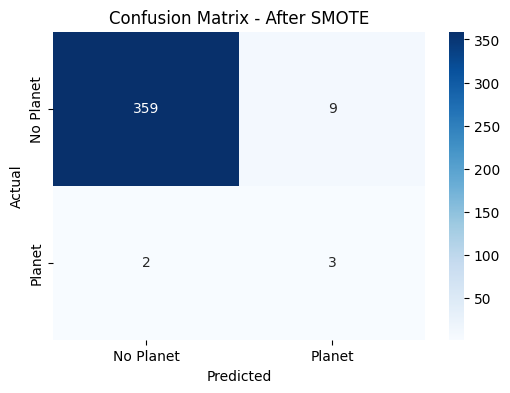

              precision    recall  f1-score   support

   No Planet       0.99      0.98      0.98       368
      Planet       0.25      0.60      0.35         5

    accuracy                           0.97       373
   macro avg       0.62      0.79      0.67       373
weighted avg       0.98      0.97      0.98       373



In [20]:
# test model2 on real unseen test data
X_test_clean = np.nan_to_num(X_test, nan=0.0)
X_test_cnn2 = X_test_clean.reshape(X_test_clean.shape[0], X_test_clean.shape[1], 1)

y_pred2_prob = model2.predict(X_test_cnn2)
y_pred2 = (y_pred2_prob > 0.5).astype(int).flatten()

cm2 = confusion_matrix(y_test_cnn, y_pred2)

plt.figure(figsize=(6,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Planet', 'Planet'],
            yticklabels=['No Planet', 'Planet'])
plt.title("Confusion Matrix - After SMOTE")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_test_cnn, y_pred2, target_names=['No Planet', 'Planet']))

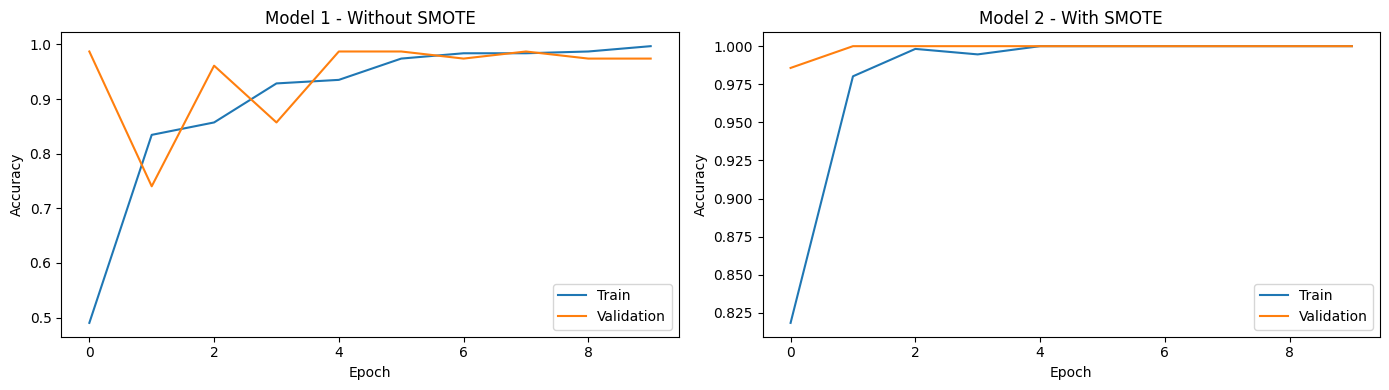

In [21]:
# side by side comparison of model1 vs model2 training
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# model 1 - without SMOTE
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model 1 - Without SMOTE')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# model 2 - with SMOTE
axes[1].plot(history2.history['accuracy'], label='Train')
axes[1].plot(history2.history['val_accuracy'], label='Validation')
axes[1].set_title('Model 2 - With SMOTE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

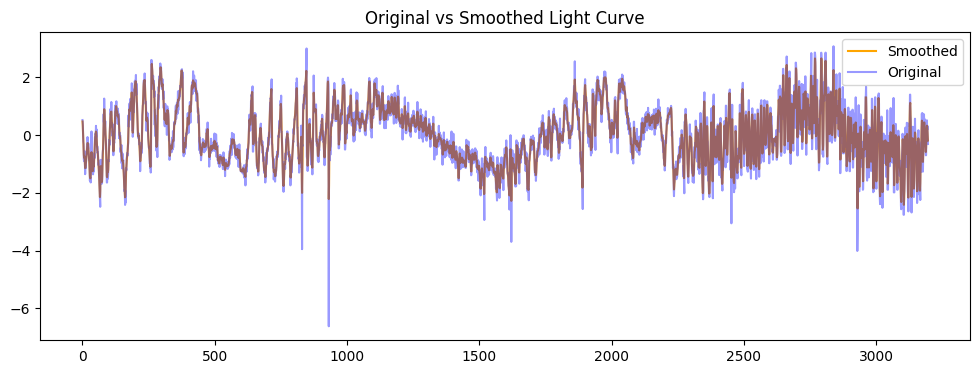

In [22]:
from scipy.ndimage import gaussian_filter1d

def smooth_flux(X, sigma=1):
    return np.array([gaussian_filter1d(x, sigma=sigma) for x in X])

X_train_smooth = smooth_flux(np.nan_to_num(X_train, nan=0.0))
X_test_smooth = smooth_flux(np.nan_to_num(X_test, nan=0.0))

plt.figure(figsize=(12, 4))
plt.plot(X_train_smooth[0], label='Smoothed', color='orange')
plt.plot(np.nan_to_num(X_train, nan=0.0)[0], label='Original', alpha=0.4, color='blue')
plt.title("Original vs Smoothed Light Curve")
plt.legend()
plt.show()

In [23]:
from imblearn.over_sampling import SMOTE

X_train_sm_flat = X_train_smooth.reshape(X_train_smooth.shape[0], -1)
sm = SMOTE(random_state=42)
X_final, y_final = sm.fit_resample(X_train_sm_flat, y_train_cnn)
X_final_cnn = X_final.reshape(X_final.shape[0], X_final.shape[1], 1)

model3 = models.Sequential([
    layers.Conv1D(16, kernel_size=5, activation='relu', input_shape=(X_final_cnn.shape[1], 1)),
    layers.MaxPooling1D(pool_size=4),
    layers.Conv1D(32, kernel_size=5, activation='relu'),
    layers.MaxPooling1D(pool_size=4),
    layers.Conv1D(64, kernel_size=5, activation='relu'),
    layers.MaxPooling1D(pool_size=4),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history3 = model3.fit(
    X_final_cnn, y_final,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.7194 - loss: 0.5351 - val_accuracy: 0.9857 - val_loss: 0.3702
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.9191 - loss: 0.2494 - val_accuracy: 0.9929 - val_loss: 0.0982
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9532 - loss: 0.1476 - val_accuracy: 0.9857 - val_loss: 0.1159
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.9766 - loss: 0.0813 - val_accuracy: 1.0000 - val_loss: 0.0212
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.9784 - loss: 0.0581 - val_accuracy: 1.0000 - val_loss: 0.0105
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.9910 - loss: 0.0388 - val_accuracy: 1.0000 - val_loss: 0.0109
Epoch 7/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.9892 - loss: 0.0379 - val_accuracy: 0.9929 - val_loss: 0.0229
Epoch 8/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9910 - loss: 0.0332 - val_accuracy: 1.0000 - val_loss: 0.

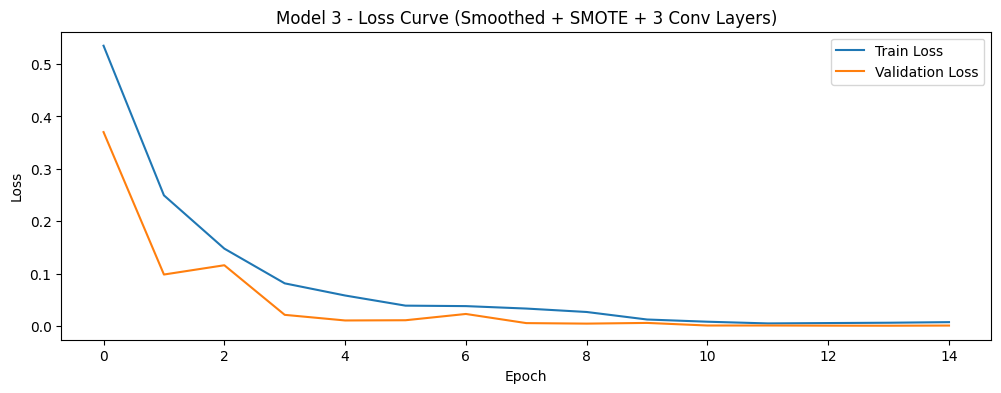

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


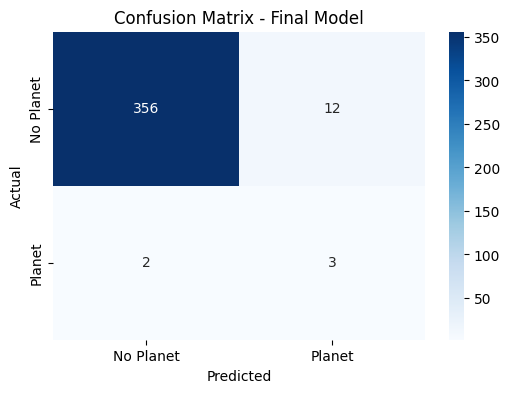

              precision    recall  f1-score   support

   No Planet       0.99      0.97      0.98       368
      Planet       0.20      0.60      0.30         5

    accuracy                           0.96       373
   macro avg       0.60      0.78      0.64       373
weighted avg       0.98      0.96      0.97       373



In [24]:
plt.figure(figsize=(12, 4))
plt.plot(history3.history['loss'], label='Train Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.title("Model 3 - Loss Curve (Smoothed + SMOTE + 3 Conv Layers)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

X_test_cnn3 = X_test_smooth.reshape(X_test_smooth.shape[0], X_test_smooth.shape[1], 1)
y_pred3_prob = model3.predict(X_test_cnn3)
y_pred3 = (y_pred3_prob > 0.5).astype(int).flatten()

cm3 = confusion_matrix(y_test_cnn, y_pred3)
plt.figure(figsize=(6,4))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Planet', 'Planet'],
            yticklabels=['No Planet', 'Planet'])
plt.title("Confusion Matrix - Final Model")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_test_cnn, y_pred3, target_names=['No Planet', 'Planet']))

In [25]:
model2.save("exoplanet_detector.keras")
print("Model saved successfully")

Model saved successfully


In [26]:
from google.colab import files
files.download("exoplanet_detector.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


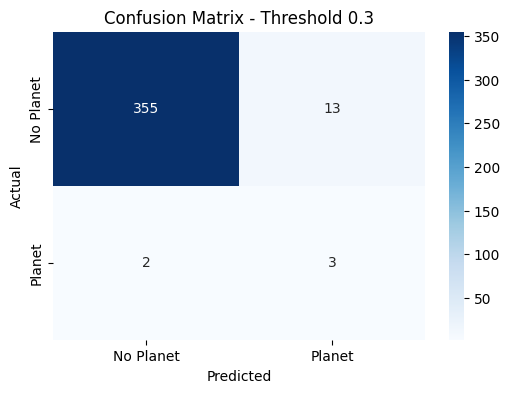

              precision    recall  f1-score   support

   No Planet       0.99      0.96      0.98       368
      Planet       0.19      0.60      0.29         5

    accuracy                           0.96       373
   macro avg       0.59      0.78      0.63       373
weighted avg       0.98      0.96      0.97       373



In [27]:
import numpy as np
# Assuming X_test and model2 are defined from earlier cells.
X_test_clean = np.nan_to_num(X_test, nan=0.0)
X_test_cnn2 = X_test_clean.reshape(X_test_clean.shape[0], X_test_clean.shape[1], 1)
y_pred2_prob = model2.predict(X_test_cnn2)

y_pred_low = (y_pred2_prob > 0.3).astype(int).flatten()

cm_low = confusion_matrix(y_test_cnn, y_pred_low)
plt.figure(figsize=(6,4))
sns.heatmap(cm_low, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Planet', 'Planet'],
            yticklabels=['No Planet', 'Planet'])
plt.title("Confusion Matrix - Threshold 0.3")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_test_cnn, y_pred_low, target_names=['No Planet', 'Planet']))

In [29]:
model2.save("exoplanet_detector_final.keras")